In [6]:
%matplotlib widget
import numpy as np
import tqdm
import ipywidgets
import matplotlib.pyplot as plt
from scipy.constants import k, e
from scipy.interpolate import RegularGridInterpolator
import sys
sys.path.append('../../theory/sedov_theory/python/')
from sedov_theory import SedovTalorProblem
from analysis_tool import CastroSimulation

In [2]:
run_dir = '../run/'
file_start = 'plt_1d_'

In [ ]:
cs = CastroSimulation(run_dir, file_start)

# Check conservation of energy

In [ ]:
def compute_energy(time):
    """
    Compute energy in ergs/m

    Args:
        time: time in seconds

    Returns:
        energy in ergs/m
    """
    # Thermal and kinetic energy
    r, q, t = cs.extract_data( time, 'rho_E', 0)
    dr = r[1] - r[0]
    E_th_and_kin = 2*np.pi*dr * (q*r).sum() # erg/m

    # Ionization energy
    r, q, t = cs.extract_data( time, 'rho_Hp', 0)
    M_ions = 2*np.pi*dr * (q*r).sum()
    E_ioniz = 13.6 * (q_e*1e7) * M_ions / (m_p * 1e3)

    return t, E_th_and_kin, E_ioniz

In [ ]:
t = []
E = []
E_ioniz = []
Etot = []
for time in tqdm.tqdm(np.linspace(0, 5e-9, 50)):
    t0, e, e_ioniz = compute_energy(time)
    t.append(t0)
    E.append(e)
    E_ioniz.append(e_ioniz)
    Etot.append(e + e_ioniz)
plt.plot(t, E)
plt.plot(t, E_ioniz, 'r-')
plt.plot(t, Etot, 'k--')
plt.grid()

# Compare data with theory

In [4]:
# Calculate analytical solution
gamma = 5./3
rho = 1.67e-6 # g / cm^3
E = 4400 # erg / cm

sol = SedovTalorProblem(gamma, E, rho)

In [ ]:
plt.figure(figsize=(5, 4))
plt.clf()
level = 0
time = 2e-9

labels = {
    'rho_Hn': 'Density of Hydrogen atoms',
    'rho_Hp': 'Hydrogen ions',
    'density': 'Total Hydrogen density',
}
colors = {
    'rho_Hn': 'gray',
    'rho_Hp': 'blue',
    'density': 'black'
}

for quantity in ['density', 'rho_Hp']:
    r, q, t = cs.extract_data( time, quantity, level)
    # Convert r from cm to microns
    # Convert massic density in cc to number density in cc
    plt.plot(1e4*r, q/1.67e-6, '-', label=labels[quantity], color=colors[quantity])

# Plot Sedov-Taylor solution
r_th = r
plt.plot( 1e4*r_th, sol.evaluate( 'density', r, t )/1.67e-6, 'k--', label='Sedov-Taylor theory' )
plt.legend(loc=2)

plt.ylabel(r'Density (10$^{18}$ cm$^{-3}$)')
plt.xlabel(r'r ($\mu m$)')
plt.title(f'Density at t={t*1.e9:.1f} ns')
plt.xlim(0, 150)

In [ ]:
plt.figure(figsize=(5, 4))
plt.clf()
level = 0
time = 0.3e-9

labels = {
    'T_e': 'Electron temperature',
    'T_h': 'Heavy particle temperature',
    'Temp': 'Average temperature',
}
colors = {
    'T_e': 'red',
    'T_h': 'blue',
    'Temp': 'green'
}

for quantity in ['T_e', 'T_h', 'Temp']:
    r, q, t = cs.extract_data( time, quantity, level)
    # Convert r from cm to microns
    plt.plot(1e4*r, k*q/e, '-', label=labels[quantity], color=colors[quantity])
plt.legend(loc=0)
plt.ylabel(r'Temperature (eV)')
plt.xlabel(r'r ($\mu m$)')

plt.twinx()
r, q, t = cs.extract_data( time, 'f_heavies', level)
plt.semilogy(1e4*r, q, '--', color='black')
r, q, t = cs.extract_data( time, 'X(Hp)', level)
plt.semilogy(1e4*r, q, '-', color='gray')


plt.title(f'Temperatures at t={t*1.e9:.1f} ns')
plt.xlim(0, 150)

In [ ]:
t = 0e-9

r, T, t = cs.extract_data( t, 'Temp', level=0)
plt.plot( r*1e4, k*T/e, label='Temperature' )
plt.legend(loc=3)
plt.ylim(0,30)
plt.ylabel('Temperature (eV)')
plt.grid()
plt.twinx()
r, n, t = cs.extract_data( t, 'density', level=0)
plt.plot( r*1.e4, n/1.67e-6 * 1.e24, color='r', label='heavies density' )
plt.xlim(0,100)
r, n, t = cs.extract_data( t, 'rho_Hp', level=0)
plt.plot( r*1.e4, n/1.67e-6 * 1.e24, color='g' , label='electrons density' )
plt.legend(loc=5)
plt.xlim(0,100)
plt.ylim(0, 1.1e24)
plt.ylabel('Density (m^-3)')
plt.xlabel('r (microns)')

In [ ]:
path = 'Castro_benchmark/1T_AllOff'

for variable, path_end in zip(['density', 'rho_Hp'], ['_heavies', '_electrons']):

    # Extract data from different time
    # Note that time is not regularly spaced
    q_arr = []
    rmax_arr = []
    for time in tqdm.tqdm( cs.output_times ):
        r, q, t = cs.extract_data(time, variable, level=0)
        rmax = r[np.argmax(q)]
        rmax_arr.append(rmax)
        q_arr.append(q)
    q_arr = np.stack(q_arr)
    t_arr = cs.output_times.copy()
    r_arr = r

    # Interpolate on a grid with regularly-spaced time
    interp = RegularGridInterpolator(points=(t_arr, r_arr), values=q_arr, bounds_error=False, fill_value=None)
    t_interp, r_interp = np.meshgrid(
        np.linspace(0, t_arr.max(), 1001),
        np.linspace(0, r_arr.max(), 1001), indexing='ij')
    q_interp = interp((t_interp, r_interp))

    np.save(path + path_end + '.npy', q_interp.T/1.67e-6 * 1.e24)

In [ ]:
plt.figure(figsize=(6, 2))
plt.imshow(q_interp.T/1.67e-6, origin='lower',
           extent=[0, t_arr.max()*1.e9, 0, r_arr.max()*1.e4],
           aspect='auto', vmax=5)
cb = plt.colorbar()
cb.set_label(r'H density (10$^{18}$ cm$^{-3}$)')
#plt.plot(t_arr, rmax_arr, 'r-')
#r_analytical = sol.blast_radius(t_arr)
#plt.plot(t_arr*1.e9, r_analytical*1.e4, 'r--', label='Sedov-Taylor theory')
#plt.legend(loc=0)
plt.ylabel(r'r ($\mu m$)')
plt.xlabel(r't (ns)')
plt.ylim(0,300)

In [33]:
paths = [
#    'Castro_benchmark/2T_old_diffusion',
    'Castro_benchmark/2T_new_diffusion',
    'Comsol_benchmark/Broks_FixNuEI'
]

ls = [':', '-', '--']

labels = ['Castro', 'Comsol']

n_h = [ np.load(path + '_heavies.npy') for path in paths ]
n_e = [ np.load(path + '_electrons.npy') for path in paths ]
T_h = [ np.load(path + '_T_heavies.npy') for path in paths ]
T_e = [ np.load(path + '_T_electrons.npy') for path in paths ]

In [34]:
def plot_density(it=500):
    r = np.linspace(0, 0.03*1.e4, 1001)
    for i in range(len(paths)):
        plt.plot( r, n_h[i][:,it], ls[i], label=labels[i] + ': heavies', lw=1, color='k')
        plt.plot( r, n_e[i][:,it], ls[i], label=labels[i] + ': electrons', lw=1, color='r')
    plt.ylim( 0, 4e24 )
    #plt.xlim(0,100)
    plt.legend(loc=0)
    plt.grid()
    plt.ylabel('Density (m^-3)')
    plt.xlabel('r (microns)')

In [35]:
def plot_temperature(it=500):
    r = np.linspace(0, 0.03*1.e4, 1001)
    for i in range(len(paths)):
        plt.plot( r, T_h[i][:,it], ls[i], label=labels[i] + ': heavies', lw=1, color='k')
        plt.plot( r, T_e[i][:,it], ls[i], label=labels[i] + ': electrons', lw=1, color='r')
#    plt.ylim( 0, 4e24 )
    #plt.xlim(0,100)
    plt.legend(loc=0)
    plt.grid()
    plt.ylabel('Temperature (eV)')
    plt.xlabel('r (microns)')

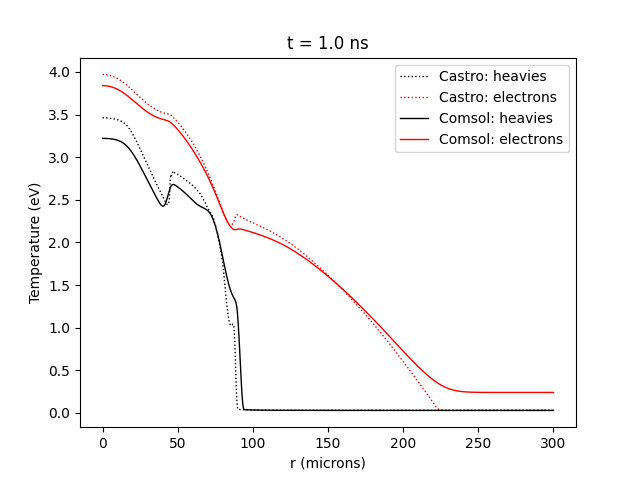

In [32]:
it = 100
plt.figure()
plt.clf()
plot_temperature(it)
plt.title('t = %.1f ns' %(10*it/1000) )
plt.grid()

In [36]:
for it in tqdm.tqdm(range(0,1000,20)):
    plt.clf()
    plt.subplot(211)
    plot_density(it)
    plt.title('t = %.1f ns' %(10*it/1000) )
    plt.subplot(212)
    plot_temperature(it)
    plt.savefig('img/img%05d.png' %it)

100%|██████████| 50/50 [00:02<00:00, 18.10it/s]


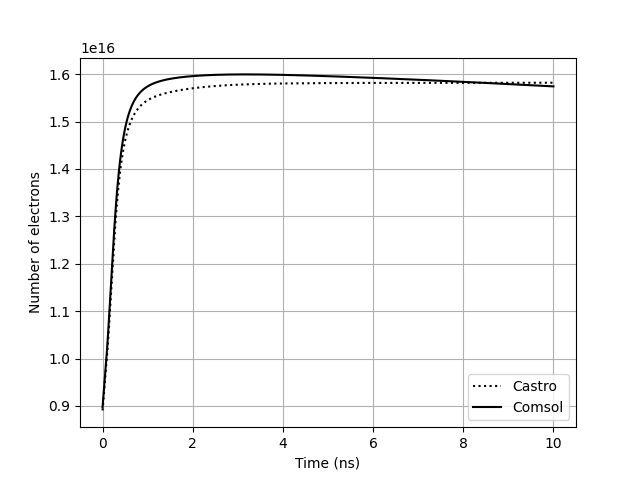

In [42]:
r = np.linspace(0, 0.03e-2, 1001)
dr = r[1] - r[0]
t = np.linspace(0,10, 1001)
plt.figure()
for i in range(len(labels)):
    plt.plot( t, (2*np.pi*r[:, np.newaxis]*dr*n_e[i]).sum(axis=0), label=labels[i], ls=ls[i], color='k')
plt.legend()
plt.ylabel('Number of electrons')
plt.xlabel('Time (ns)')
plt.grid()